# EDA - SIA APAC de Medicamentos (AM)

Análise exploratória de dados sobre dispensações de medicamentos para Doenca de Gaucher registradas em APACs do SIA/SUS em durante 2025.

## Contexto clínico

A Doenca de Gaucher é um distúrbio lisossomal raro tratado, no SUS, com duas estrategias:

- TRE - Terapia de Reposicao Enzimatica (parenteral, dose biquinzenal):
    - `0604240031` Imiglucerase 400 U
    - `0604240058` Alfavelaglicerase 400 U
    - `0604240023` Alfataliglicerase 200 U
- ISS - Inibicao de Sintese de Substrato (oral, capsulas diarias):
    - `0604630018` Miglustate 100 mg

## Objetivos da EDA

1. Diagnosticar qualidade e completude dos dados.
2. Caracterizar o mix de medicamentos no recorte.
3. Descrever pacientes (sexo, idade, raca/cor, antropometria).
4. Avaliar distribuicao temporal e geografica.
5. Mapear comorbidades via CID.
6. Avaliar continuidade da dispensacao por paciente.
7. Aplicar estatistica descritiva e testes de hipotese para entender distribuicao
   e relacionamentos entre variaveis.

## Limitações da EDA

- Sem mortalidade: necessario integrar `SIM` via record linkage.
- Sem custo: AM nao traz `vl_apac_aprovada` real; precisa da `PA`.
- Sem desfechos clinicos: hemoglobina, plaquetas, volumes hepatico/esplenico
  nao constam na APAC.
- DDD nao calculavel: ausencia de quantidade dispensada por linha.
- Recorte 1 estado / 1 ano: nao representa a coorte nacional.

In [3]:
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

In [4]:
base_dir = Path("..").resolve() if Path.cwd().name == "notebooks" else Path.cwd()
parquet_glob = str(base_dir / "data" / "raw" / "AM**" / "*.parquet")
parquet_glob

'/mnt/c/Dev/UFJF-DCC166/data/raw/AM**/*.parquet'

In [5]:
con = duckdb.connect(database=":memory:")

con.execute(
    f"""
    create or replace view tb_apac_medicamento_raw as
    select *
    from read_parquet('{parquet_glob}', union_by_name=true, filename=true);
    """
)

con.execute(
    """
    create or replace view tb_apac_medicamento as
    select
        AP_MVM AS dt_movimento_processamento,
        AP_CONDIC AS sg_tipo_gestao,
        AP_GESTAO AS cd_gestao_uf_municipio,
        AP_CODUNI AS cd_cnes_estabelecimento,
        AP_AUTORIZ AS cd_apac,
        AP_CMP AS dt_atendimento,
        AP_PRIPAL AS cd_procedimento_principal,
        TRY_CAST(AP_VL_AP AS DOUBLE) AS vl_apac_aprovada,
        AP_UFMUN AS cd_uf_municipio_estabelecimento,
        AP_TPUPS AS ct_tipo_estabelecimento,
        AP_TIPPRE AS ct_tipo_prestador,
        AP_MN_IND AS ct_estabelecimento_mantido_individual,
        AP_CNPJCPF AS cd_cnpj_estabelecimento,
        AP_CNPJMNT AS cd_cnpj_mantenedora,
        AP_CNSPCN AS cd_cns_paciente,
        AP_COIDADE AS cd_codigo_idade,
        try_cast(AP_NUIDADE as integer) AS nu_idade_paciente,
        AP_SEXO AS sg_sexo_paciente,
        case AP_RACACOR 
                when '01' then 'Branca'
                when '02' then 'Preta'
                when '03' then 'Parda'
                when '04' then 'Amarela'
                when '05' then 'Indígena'
                when '99' then 'Sem informação'
                else null
        end as ct_raca_cor_paciente,
        AP_MUNPCN AS cd_uf_municipio_residencia,
        AP_UFNACIO AS cd_nacionalidade_paciente,
        AP_CEPPCN AS cd_cep_paciente,
        case AP_UFDIF 
            when 1 then true
            when 0 then false
            else null
        end as fl_uf_residencia_diferente,
        case AP_MNDIF 
            when 1 then true
            when 0 then false
            else null
        end as fl_municipio_residencia_diferente,
        AP_DTINIC AS dt_inicio_validade,
        AP_DTFIM AS dt_fim_validade,
        AP_TPATEN AS ct_tipo_atendimento_apac,
        AP_TPAPAC AS ct_tipo_apac,
        AP_MOTSAI AS ct_motivo_saida_permanencia,
        case AP_OBITO
            when '1' then true
            when '0' then false
            else null
        end as fl_obito,
        case AP_ENCERR
            when '1' then true
            when '0' then false
            else null
        end as fl_encerramento,
        case AP_PERMAN
            when '1' then true
            when '0' then false
            else null
        end as fl_permanencia,
        case AP_ALTA
            when '1' then true
            when '0' then false
            else null
        end as fl_alta,
        case AP_TRANSF
            when '1' then true
            when '0' then false
            else null
        end as fl_transferencia,
        AP_DTOCOR AS dt_ocorrencia,
        AP_CODEMI AS cd_orgao_emissor,
        AP_CATEND AS ct_carater_atendimento,
        case AP_APACANT
            when '000000000000' then 'aaa'
            else AP_APACANT
        end as cd_apac_anterior,
        AP_UNISOL AS cd_cnes_solicitante,
        AP_DTSOLIC AS dt_solicitacao,
        AP_DTAUT AS dt_autorizacao,
        AP_CIDPRI AS cd_cid_principal,
        case AP_CIDSEC
            when '0000' then null
            else AP_CIDSEC
        end as cd_cid_secundario,
        case AP_CIDCAS
            when '0000' then null
            else AP_CIDCAS
        end as cd_cid_causa_associada,
        AP_ETNIA AS ct_etnia_paciente,
        cast(AM_PESO as double) AS nu_peso_kg,
        cast(AM_ALTURA as double) AS nu_altura_cm,
        case AM_TRANSPL
            when 'S' then true
            when 'N' then false
            else null
        end as fl_pos_transplante,
        cast(AM_QTDTRAN as integer) AS qt_transplantes,
        case AM_GESTANT
            when 'S' then true
            when 'N' then false
            else null
        end as fl_gestante
    FROM tb_apac_medicamento_raw
    QUALIFY row_number() OVER (PARTITION BY AP_AUTORIZ, AP_PRIPAL, AP_MVM ORDER BY AP_DTAUT DESC) = 1
    ;
    """
)

con.execute("SELECT COUNT(*) AS qt_linhas FROM tb_apac_medicamento").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,qt_linhas
0,39674422


In [6]:
con.execute("SELECT * FROM tb_apac_medicamento LIMIT 10").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,dt_movimento_processamento,sg_tipo_gestao,cd_gestao_uf_municipio,cd_cnes_estabelecimento,cd_apac,dt_atendimento,cd_procedimento_principal,vl_apac_aprovada,cd_uf_municipio_estabelecimento,ct_tipo_estabelecimento,ct_tipo_prestador,ct_estabelecimento_mantido_individual,cd_cnpj_estabelecimento,cd_cnpj_mantenedora,cd_cns_paciente,cd_codigo_idade,nu_idade_paciente,sg_sexo_paciente,ct_raca_cor_paciente,cd_uf_municipio_residencia,cd_nacionalidade_paciente,cd_cep_paciente,fl_uf_residencia_diferente,fl_municipio_residencia_diferente,dt_inicio_validade,dt_fim_validade,ct_tipo_atendimento_apac,ct_tipo_apac,ct_motivo_saida_permanencia,fl_obito,fl_encerramento,fl_permanencia,fl_alta,fl_transferencia,dt_ocorrencia,cd_orgao_emissor,ct_carater_atendimento,cd_apac_anterior,cd_cnes_solicitante,dt_solicitacao,dt_autorizacao,cd_cid_principal,cd_cid_secundario,cd_cid_causa_associada,ct_etnia_paciente,nu_peso_kg,nu_altura_cm,fl_pos_transplante,qt_transplantes,fl_gestante
0,202501,EP,120000,3542734,1224200273527,202501,0604230028,0.00,120040,43,00,M,04034526000143,04034526000143,{{|{||,4,59,M,Parda,120040,010,69918298,False,True,20241101,20250131,06,2,21,False,False,True,False,False,,E120000001,01,000000000000,2000857,20241017,20241101,F200,None,None,,75.00,165.00,False,0,False
1,202501,EP,120000,3542734,1224200285320,202501,0604230044,0.00,120040,43,00,M,04034526000143,04034526000143,{{{{}~~{},4,47,F,Branca,120045,010,69925000,False,True,20241201,20250228,06,2,21,False,False,True,False,False,,E120000001,01,000000000000,0986925,20241021,20241122,F313,None,None,,98.00,165.00,False,0,False
2,202501,EP,120000,3542734,1225200014874,202501,0604230044,0.00,120040,43,00,M,04034526000143,04034526000143,{{{}}~||,4,26,M,Parda,120040,010,69903279,False,True,20250116,20250331,06,1,21,False,False,True,False,False,,E120000001,01,000000000000,2000857,20250113,20250116,F311,None,None,,65.00,171.00,False,0,False
3,202501,EP,120000,7334710,1225200000190,202501,0604230044,0.00,120020,43,00,M,04034526000143,04034526000143,{{{{~||}{{,4,22,F,Parda,120020,010,69980000,False,True,20250102,20250331,06,1,21,False,False,True,False,False,,E120000001,01,000000000000,3733211,20241129,20250102,F208,None,None,,62.00,165.00,False,0,False
4,202501,EP,120000,3542734,1224200271987,202501,0604550022,0.00,120040,43,00,M,04034526000143,04034526000143,{{~|},4,13,M,Preta,120040,010,69907860,False,True,20241101,20250131,06,2,21,False,False,True,False,False,,E120000001,01,000000000000,0128619,20240627,20241030,G800,None,None,,26.00,120.00,False,0,False
5,202501,EP,120000,3542734,1224200311191,202501,0604550022,0.00,120040,43,00,M,04034526000143,04034526000143,{{{{}{}{,4,17,F,Parda,120040,010,69915022,False,True,20241219,20250228,06,2,21,False,False,True,False,False,,E120000001,01,000000000000,0128619,20240912,20241219,G824,None,None,,600.00,160.00,False,0,False
6,202501,EP,120000,3542734,1224200286793,202501,0604200013,24.60,120040,43,00,M,04034526000143,04034526000143,{|{}~},4,60,F,Parda,120040,010,69902379,False,True,20241201,20250228,06,2,21,False,False,True,False,False,,E120000001,01,000000000000,4082524,20241125,20241125,G20,None,None,,469.00,147.00,False,0,False
7,202501,EP,120000,3542734,1225200002961,202501,0604130023,0.00,120040,43,00,M,04034526000143,04034526000143,{{}|{{{|,4,84,F,Parda,120050,010,69940000,False,True,20250107,20250331,06,1,21,False,False,True,False,False,,E120000001,01,000000000000,2001586,20241127,20250107,G300,None,None,,73.00,160.00,False,0,False
8,202501,EP,120000,3542734,1225200016172,202501,0604500017,0.00,120040,43,00,M,04034526000143,04034526000143,{~|{}{,4,49,F,Parda,120040,010,69905438,False,True,20250121,20250331,06,1,21,False,False,True,False,False,,E120000001,01,000000000000,4082524,20250121,20250121,R521,None,None,,72.00,150.00,False,0,False
9,202501,EP,120000,3542734,1224200286420,202501,0604590024,0.00,120040,43,00,M,04034526000143,04034526000143,{{}~|~|,4,15,M,Parda,120040

In [7]:
con.execute(
    """
    CREATE OR REPLACE VIEW tb_apac_medicamento_gaucher AS
    WITH base AS (
        SELECT
            *,
            trim(cd_procedimento_principal) AS cd_proc,
            CASE trim(cd_procedimento_principal)
                WHEN '0604240031' THEN 'Imiglucerase 400 U'
                WHEN '0604240058' THEN 'Alfavelaglicerase 400 U'
                WHEN '0604240023' THEN 'Alfataliglicerase 200 U'
                WHEN '0604630018' THEN 'Miglustate 100 mg'
            END AS nm_medicamento,
            CASE trim(cd_procedimento_principal)
                WHEN '0604630018' THEN 'ISS'
                ELSE 'TRE'
            END AS ct_classe_terapeutica,
            TRY_CAST(nu_idade_paciente AS INTEGER) AS nu_idade_raw,
            TRY_CAST(nu_peso_kg AS DOUBLE) AS nu_peso_kg_num,
            TRY_CAST(nu_altura_cm AS DOUBLE) AS nu_altura_cm_num
        FROM tb_apac_medicamento
        WHERE trim(cd_procedimento_principal) IN (
            '0604240031', '0604240058', '0604240023', '0604630018'
        )
    )
    SELECT
        b.*,
        CASE cd_codigo_idade
            WHEN '4' THEN nu_idade_raw
            WHEN '5' THEN nu_idade_raw
            WHEN '3' THEN nu_idade_raw / 12.0
            WHEN '2' THEN nu_idade_raw / 365.0
            ELSE nu_idade_raw
        END AS nu_idade_anos,
        -- Peso plausivel: 1 - 250 kg (acima disso e' erro de digitacao)
        CASE
            WHEN nu_peso_kg_num BETWEEN 1 AND 250 THEN nu_peso_kg_num
            ELSE NULL
        END AS nu_peso_kg_ok,
        -- Altura plausivel: 30 - 230 cm
        CASE
            WHEN nu_altura_cm_num BETWEEN 30 AND 230 THEN nu_altura_cm_num
            ELSE NULL
        END AS nu_altura_cm_ok,
        -- IMC apenas quando peso e altura sao plausiveis
        CASE
            WHEN nu_peso_kg_num NOT BETWEEN 1 AND 250 THEN NULL
            WHEN nu_altura_cm_num NOT BETWEEN 30 AND 230 THEN NULL
            ELSE nu_peso_kg_num / power(nu_altura_cm_num / 100.0, 2)
        END AS nu_imc,
        substr(dt_atendimento, 1, 4) AS dt_ano_competencia,
        substr(dt_atendimento, 5, 2) AS dt_mes_competencia,
        TRY_CAST(strptime(dt_atendimento || '01', '%Y%m%d') AS DATE)
            AS dt_competencia_date,
        substr(cd_uf_municipio_estabelecimento, 1, 2) AS cd_uf_estabelecimento,
        substr(cd_uf_municipio_residencia, 1, 2) AS cd_uf_residencia,
        -- Tempo entre solicitacao e autorizacao (dias)
        CASE
            WHEN dt_solicitacao IS NULL OR dt_autorizacao IS NULL THEN NULL
            WHEN length(trim(dt_solicitacao)) <> 8 OR length(trim(dt_autorizacao)) <> 8 THEN NULL
            ELSE date_diff('day',
                TRY_CAST(strptime(dt_solicitacao, '%Y%m%d') AS DATE),
                TRY_CAST(strptime(dt_autorizacao, '%Y%m%d') AS DATE)
            )
        END AS qt_dias_solic_autoriz
    FROM base b;
    """
)

con.execute(
    """
    SELECT
        COUNT(*) AS qt_linhas,
        COUNT(DISTINCT cd_apac) AS qt_apacs,
        COUNT(DISTINCT cd_cns_paciente) AS qt_pacientes,
        COUNT(DISTINCT cd_cnes_estabelecimento) AS qt_estabelecimentos,
        MIN(dt_competencia_date) AS dt_min,
        MAX(dt_competencia_date) AS dt_max
    FROM tb_apac_medicamento_gaucher;
    """
).df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,qt_linhas,qt_apacs,qt_pacientes,qt_estabelecimentos,dt_min,dt_max
0,8673,4226,798,124,2024-11-01,2025-12-01


## 1. Visão geral e qualidade dos dados
- Volumetria: quantas linhas, quantas APACs distintas e quantos pacientes distintos compoem o recorte Gaucher.
- Cobertura temporal: quais competencias estao presentes (espera-se 2025-01 a 2025-12).
- Completude: quais colunas tem muitos valores faltantes.

In [8]:
df_panorama = con.execute(
    """
    SELECT
        nm_medicamento,
        ct_classe_terapeutica,
        COUNT(*) AS qt_linhas,
        COUNT(DISTINCT cd_apac) AS qt_apacs,
        COUNT(DISTINCT cd_cns_paciente) AS qt_pacientes,
        MIN(dt_competencia_date) AS dt_min,
        MAX(dt_competencia_date) AS dt_max
    FROM tb_apac_medicamento_gaucher
    GROUP BY ROLLUP(nm_medicamento, ct_classe_terapeutica)
    ORDER BY qt_linhas DESC NULLS FIRST;
    """
).df()

df_panorama

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,nm_medicamento,ct_classe_terapeutica,qt_linhas,qt_apacs,qt_pacientes,dt_min,dt_max
0,None,None,8673,4226,798,2024-10-01,2025-12-01
1,Imiglucerase 400 U,TRE,5882,2863,539,2024-10-01,2025-12-01
2,Imiglucerase 400 U,None,5882,2863,539,2024-10-01,2025-12-01
3,Alfataliglicerase 200 U,TRE,2183,1098,208,2025-01-01,2025-12-01
4,Alfataliglicerase 200 U,None,2183,1098,208,2025-01-01,2025-12-01
5,Alfavelaglicerase 400 U,TRE,345,150,42,2025-01-01,2025-12-01
6,Alfavelaglicerase 400 U,None,345,150,42,2025-01-01,2025-12-01
7,Miglustate 100 mg,None,263,116,26,2025-01-01,2025-12-01
8,Miglustate 100 mg,ISS,263,116,26,2025-01-01,2025-12-01


In [9]:
qt_total = con.execute("SELECT COUNT(*) FROM tb_apac_medicamento_gaucher").fetchone()[0]
colunas = [c[0] for c in con.execute("DESCRIBE tb_apac_medicamento_gaucher").fetchall()]

selects = ",\n        ".join(
    f"""SUM(CASE
        WHEN {c} IS NULL THEN 1
        WHEN trim(CAST({c} AS VARCHAR)) = '' THEN 1
        WHEN regexp_full_match(trim(CAST({c} AS VARCHAR)), '^0+$') THEN 1
        ELSE 0
    END) AS {c}"""
    for c in colunas
)
df_nulos = (
    con.execute(f"SELECT {selects} FROM tb_apac_medicamento_gaucher;")
    .df()
    .T.rename(columns={0: "qt_nulos"})
)
df_nulos["pc_nulos"] = (df_nulos["qt_nulos"] / qt_total * 100).round(2)
df_nulos = df_nulos.sort_values("pc_nulos", ascending=False)
df_nulos.head(20)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,qt_nulos,pc_nulos
ct_etnia_paciente,"8,673.00",100.00
cd_cid_causa_associada,"8,673.00",100.00
cd_cid_secundario,"8,673.00",100.00
ct_tipo_prestador,"8,673.00",100.00
dt_ocorrencia,"8,661.00",99.86
qt_transplantes,"8,651.00",99.75
cd_apac_anterior,"8,409.00",96.96
qt_dias_solic_autoriz,"5,464.00",63.00
cd_cnes_solicitante,"4,602.00",53.06
dt_solicitacao,"1,579.00",18.21


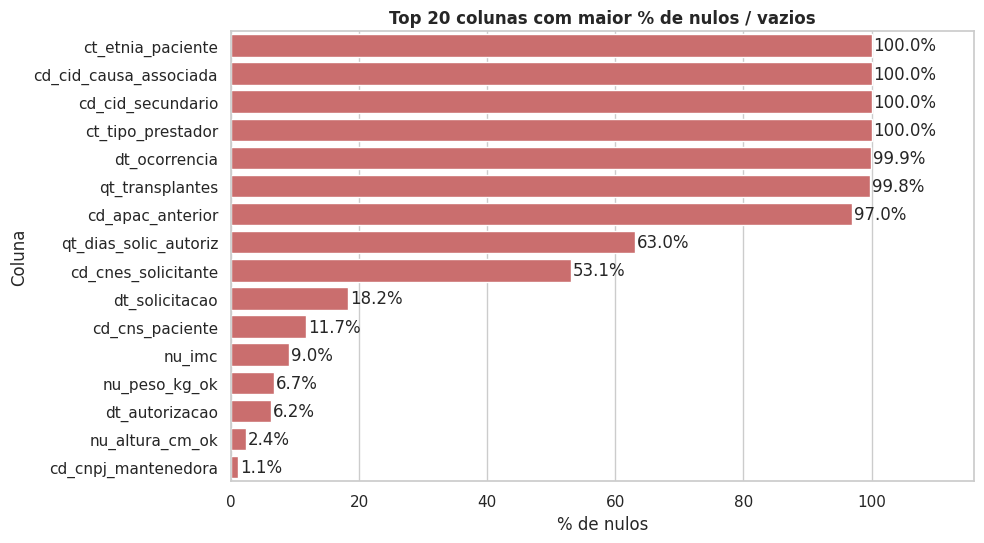

In [10]:
top_nulos = df_nulos[df_nulos["pc_nulos"] > 0].head(20)

if top_nulos.empty:
    print("Nenhuma coluna com nulos/vazios detectada.")
else:
    fig, ax = plt.subplots(figsize=(10, max(4, len(top_nulos) * 0.35)))
    sns.barplot(
        x=top_nulos["pc_nulos"],
        y=top_nulos.index,
        color="#d95f5f",
        ax=ax,
    )
    ax.set_title("Top 20 colunas com maior % de nulos / vazios")
    ax.set_xlabel("% de nulos")
    ax.set_ylabel("Coluna")
    ax.set_xlim(0, max(top_nulos["pc_nulos"]) * 1.15 + 1)
    for i, v in enumerate(top_nulos["pc_nulos"]):
        ax.text(v + 0.3, i, f"{v:.1f}%", va="center")
    plt.tight_layout()
    plt.show()

## 2. Distribuição dos medicamentos

In [11]:
df_mix = con.execute(
    """
    SELECT
        nm_medicamento,
        ct_classe_terapeutica,
        COUNT(*) AS qt_apacs,
        COUNT(DISTINCT cd_cns_paciente) AS qt_pacientes
    FROM tb_apac_medicamento_gaucher
    GROUP BY nm_medicamento, ct_classe_terapeutica
    ORDER BY qt_apacs DESC;
    """
).df()

df_mix["pc_apacs"] = 100 * df_mix["qt_apacs"] / df_mix["qt_apacs"].sum()
df_mix["pc_pacientes"] = 100 * df_mix["qt_pacientes"] / df_mix["qt_pacientes"].sum()
df_mix

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,nm_medicamento,ct_classe_terapeutica,qt_apacs,qt_pacientes,pc_apacs,pc_pacientes
0,Imiglucerase 400 U,TRE,5882,539,67.82,66.13
1,Alfataliglicerase 200 U,TRE,2183,208,25.17,25.52
2,Alfavelaglicerase 400 U,TRE,345,42,3.98,5.15
3,Miglustate 100 mg,ISS,263,26,3.03,3.19


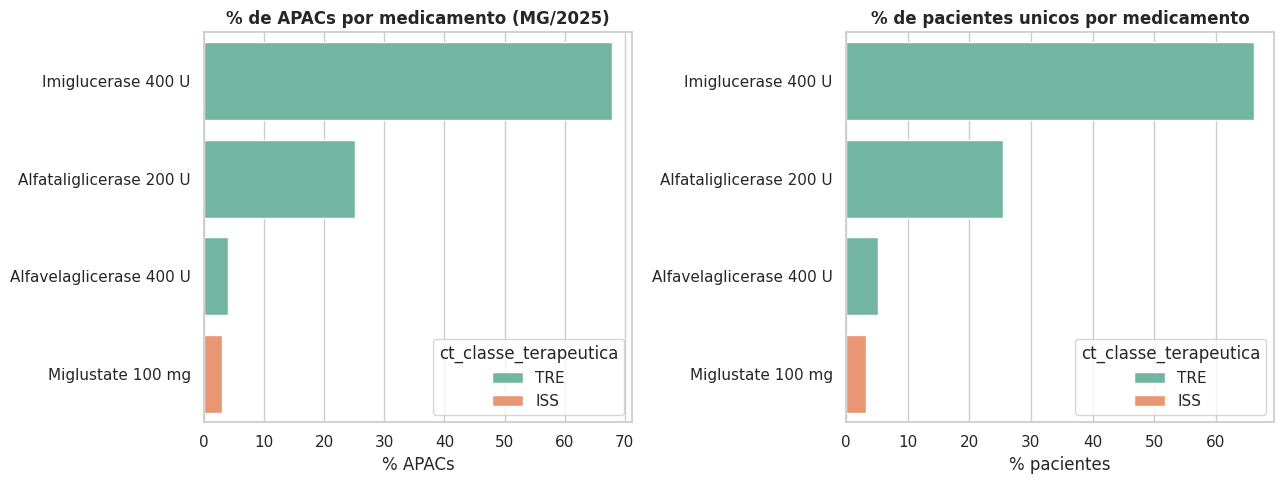

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=df_mix.sort_values("pc_apacs", ascending=False),
    x="pc_apacs",
    y="nm_medicamento",
    hue="ct_classe_terapeutica",
    dodge=False,
    ax=axes[0],
)
axes[0].set_title("% de APACs por medicamento (MG/2025)")
axes[0].set_xlabel("% APACs")
axes[0].set_ylabel("")

sns.barplot(
    data=df_mix.sort_values("pc_pacientes", ascending=False),
    x="pc_pacientes",
    y="nm_medicamento",
    hue="ct_classe_terapeutica",
    dodge=False,
    ax=axes[1],
)
axes[1].set_title("% de pacientes unicos por medicamento")
axes[1].set_xlabel("% pacientes")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 3. Demografia

In [13]:
df_sexo = con.execute(
    """
    SELECT
        CASE sg_sexo_paciente
            WHEN 'F' THEN 'Feminino'
            WHEN 'M' THEN 'Masculino'
            ELSE 'Desconhecido'
        END AS sexo,
        nm_medicamento,
        COUNT(*) AS qt_apacs,
        COUNT(DISTINCT cd_cns_paciente) AS qt_pacientes
    FROM tb_apac_medicamento_gaucher
    GROUP BY 1, 2
    ORDER BY 2, 1;
    """
).df()

pivot_sexo = df_sexo.pivot_table(
    index="nm_medicamento",
    columns="sexo",
    values="qt_pacientes",
    fill_value=0,
)
pivot_sexo["pc_F"] = 100 * pivot_sexo.get("Feminino", 0) / pivot_sexo.sum(axis=1)

pivot_sexo

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

sexo,Feminino,Masculino,pc_F
nm_medicamento,,,
Alfataliglicerase 200 U,125.00,84.00,59.81
Alfavelaglicerase 400 U,32.00,11.00,74.42
Imiglucerase 400 U,328.00,212.00,60.74
Miglustate 100 mg,19.00,7.00,73.08


In [14]:
df_idade_desc = con.execute(
    """
    SELECT
        nm_medicamento,
        COUNT(nu_idade_anos) AS qt,
        ROUND(AVG(nu_idade_anos), 1) AS nu_media,
        ROUND(MEDIAN(nu_idade_anos), 1) AS nu_mediana,
        ROUND(stddev_pop(nu_idade_anos), 1) AS nu_desvio,
        MIN(nu_idade_anos) AS nu_min,
        QUANTILE_CONT(nu_idade_anos, 0.25) AS nu_q1,
        QUANTILE_CONT(nu_idade_anos, 0.75) AS nu_q3,
        MAX(nu_idade_anos) AS nu_max
    FROM tb_apac_medicamento_gaucher
    WHERE nu_idade_anos IS NOT NULL
    GROUP BY nm_medicamento
    ORDER BY nm_medicamento;
    """
).df()

df_idade_desc

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,nm_medicamento,qt,nu_media,nu_mediana,nu_desvio,nu_min,nu_q1,nu_q3,nu_max
0,Alfataliglicerase 200 U,2183,32.70,30.00,17.90,5.00,18.00,43.00,88.00
1,Alfavelaglicerase 400 U,345,33.10,31.00,15.50,4.00,22.00,45.00,79.00
2,Imiglucerase 400 U,5882,38.30,38.00,17.90,0.08,25.00,50.00,88.00
3,Miglustate 100 mg,263,40.00,38.00,12.70,24.00,27.00,53.00,64.00


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

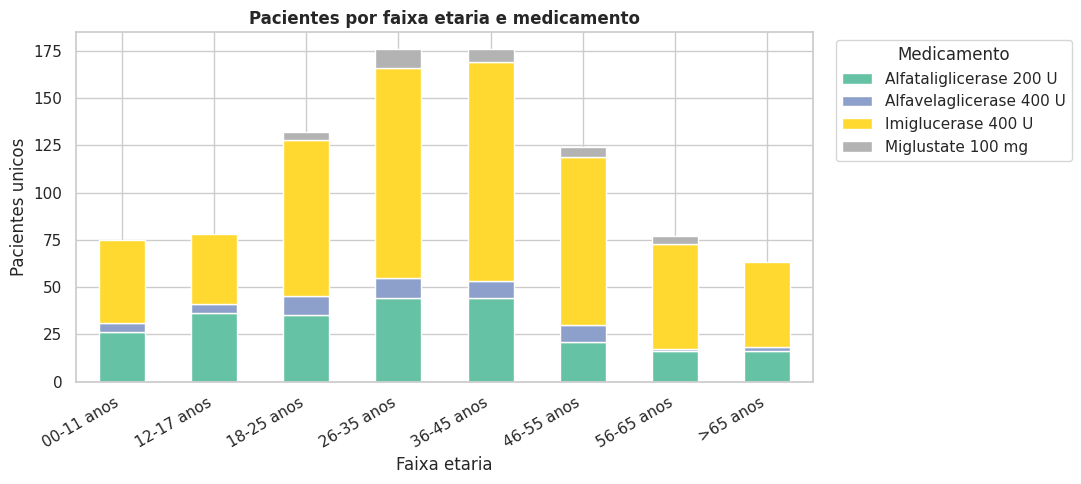

nm_medicamento,Alfataliglicerase 200 U,Alfavelaglicerase 400 U,Imiglucerase 400 U,Miglustate 100 mg
ct_faixa_etaria,,,,
00-11 anos,26.00,5.00,44.00,0.00
12-17 anos,36.00,5.00,37.00,0.00
18-25 anos,35.00,10.00,83.00,4.00
26-35 anos,44.00,11.00,111.00,10.00
36-45 anos,44.00,9.00,116.00,7.00
46-55 anos,21.00,9.00,89.00,5.00
56-65 anos,16.00,1.00,56.00,4.00
>65 anos,16.00,2.00,45.00,0.00


In [15]:
df_idade_faixa = con.execute(
    """
    SELECT
        CASE
            WHEN nu_idade_anos IS NULL THEN '99-Desconhecido'
            WHEN nu_idade_anos < 12 THEN '00-11 anos'
            WHEN nu_idade_anos < 18 THEN '12-17 anos'
            WHEN nu_idade_anos < 26 THEN '18-25 anos'
            WHEN nu_idade_anos < 36 THEN '26-35 anos'
            WHEN nu_idade_anos < 46 THEN '36-45 anos'
            WHEN nu_idade_anos < 56 THEN '46-55 anos'
            WHEN nu_idade_anos < 66 THEN '56-65 anos'
            ELSE '>65 anos'
        END AS ct_faixa_etaria,
        nm_medicamento,
        COUNT(DISTINCT cd_cns_paciente) AS qt_pacientes
    FROM tb_apac_medicamento_gaucher
    GROUP BY 1, 2
    ORDER BY 1, 2;
    """
).df()

faixa_pivot = df_idade_faixa.pivot_table(
    index="ct_faixa_etaria",
    columns="nm_medicamento",
    values="qt_pacientes",
    fill_value=0,
)

fig, ax = plt.subplots(figsize=(11, 5))
faixa_pivot.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
ax.set_title("Pacientes por faixa etaria e medicamento")
ax.set_xlabel("Faixa etaria")
ax.set_ylabel("Pacientes unicos")
ax.legend(title="Medicamento", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

faixa_pivot

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

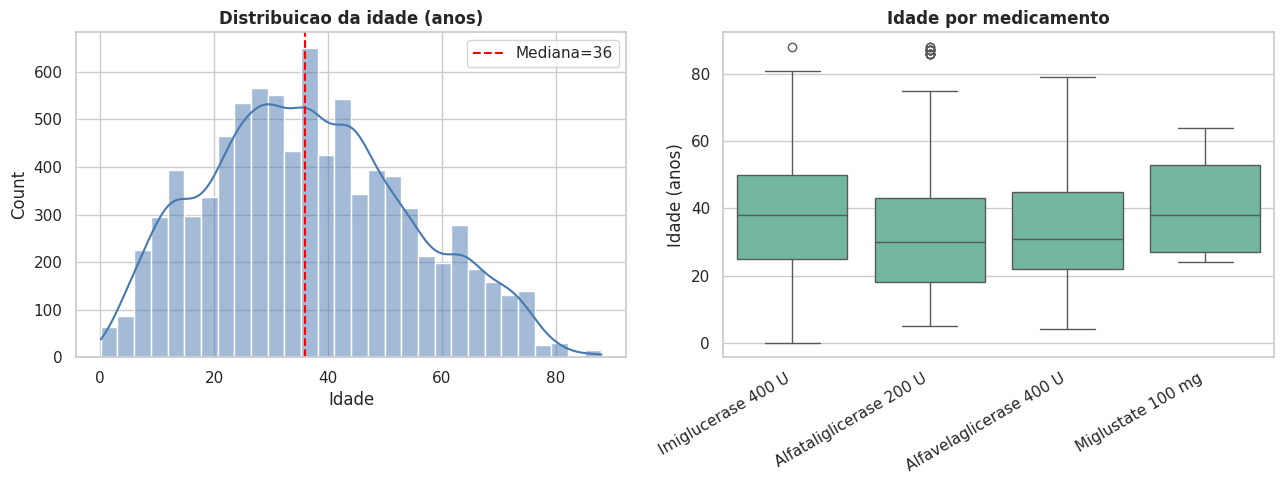

In [16]:
df_idade = con.execute(
    """
    SELECT nm_medicamento, nu_idade_anos
    FROM tb_apac_medicamento_gaucher
    WHERE nu_idade_anos IS NOT NULL AND nu_idade_anos BETWEEN 0 AND 110;
    """
).df()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df_idade["nu_idade_anos"], bins=30, kde=True, ax=axes[0], color="#4878b0")
axes[0].axvline(
    df_idade["nu_idade_anos"].median(),
    color="red",
    linestyle="--",
    label=f"Mediana={df_idade['nu_idade_anos'].median():.0f}",
)
axes[0].set_title("Distribuicao da idade (anos)")
axes[0].set_xlabel("Idade")
axes[0].legend()

sns.boxplot(data=df_idade, x="nm_medicamento", y="nu_idade_anos", ax=axes[1])
axes[1].set_title("Idade por medicamento")
axes[1].set_xlabel("")
axes[1].set_ylabel("Idade (anos)")
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

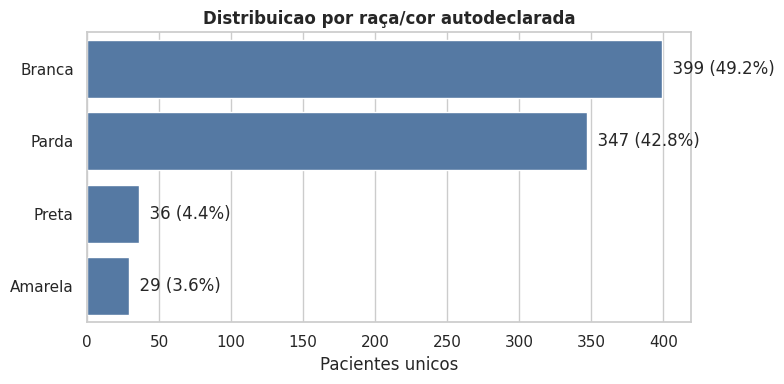

,ct_raca_cor_paciente,qt_pacientes,pc
0,Branca,399,49.20
1,Parda,347,42.80
2,Preta,36,4.40
3,Amarela,29,3.60


In [17]:
df_raca = con.execute(
    """
    SELECT
        ct_raca_cor_paciente,
        COUNT(DISTINCT cd_cns_paciente) AS qt_pacientes
    FROM tb_apac_medicamento_gaucher
    GROUP BY 1
    ORDER BY qt_pacientes DESC;
    """
).df()
df_raca["pc"] = (100 * df_raca["qt_pacientes"] / df_raca["qt_pacientes"].sum()).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=df_raca, x="qt_pacientes", y="ct_raca_cor_paciente", ax=ax, color="#4878b0"
)
for i, (q, p) in enumerate(zip(df_raca["qt_pacientes"], df_raca["pc"])):
    ax.text(q, i, f"  {q:.0f} ({p}%)", va="center")
ax.set_title("Distribuicao por raça/cor autodeclarada")
ax.set_xlabel("Pacientes unicos")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

df_raca

## 4. Distribuição temporal

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

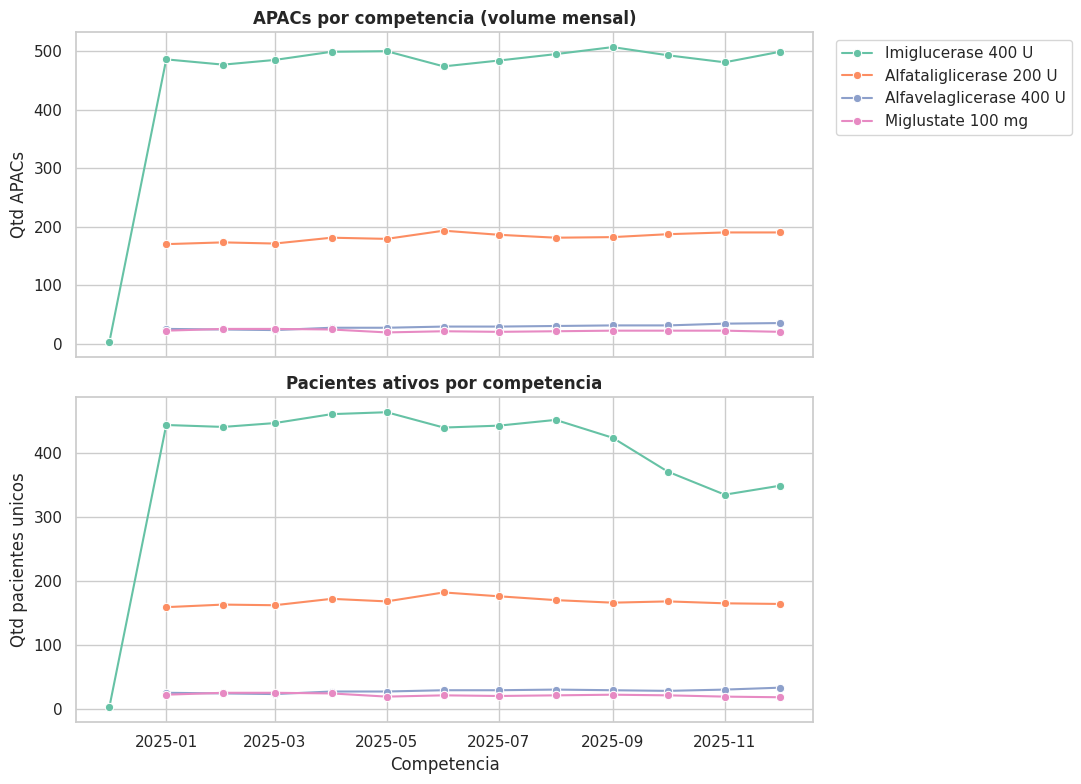

In [18]:
df_mensal = con.execute(
    """
    SELECT
        dt_competencia_date,
        nm_medicamento,
        COUNT(*) AS qt_apacs,
        COUNT(DISTINCT cd_cns_paciente) AS qt_pacientes
    FROM tb_apac_medicamento_gaucher
    WHERE dt_competencia_date IS NOT NULL
    GROUP BY 1, 2
    ORDER BY 1, 2;
    """
).df()

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

sns.lineplot(
    data=df_mensal,
    x="dt_competencia_date",
    y="qt_apacs",
    hue="nm_medicamento",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("APACs por competencia (volume mensal)")
axes[0].set_ylabel("Qtd APACs")
axes[0].legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.lineplot(
    data=df_mensal,
    x="dt_competencia_date",
    y="qt_pacientes",
    hue="nm_medicamento",
    marker="o",
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Pacientes ativos por competencia")
axes[1].set_ylabel("Qtd pacientes unicos")
axes[1].set_xlabel("Competencia")

plt.tight_layout()
plt.show()

## 5. Distribuicao geografica

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

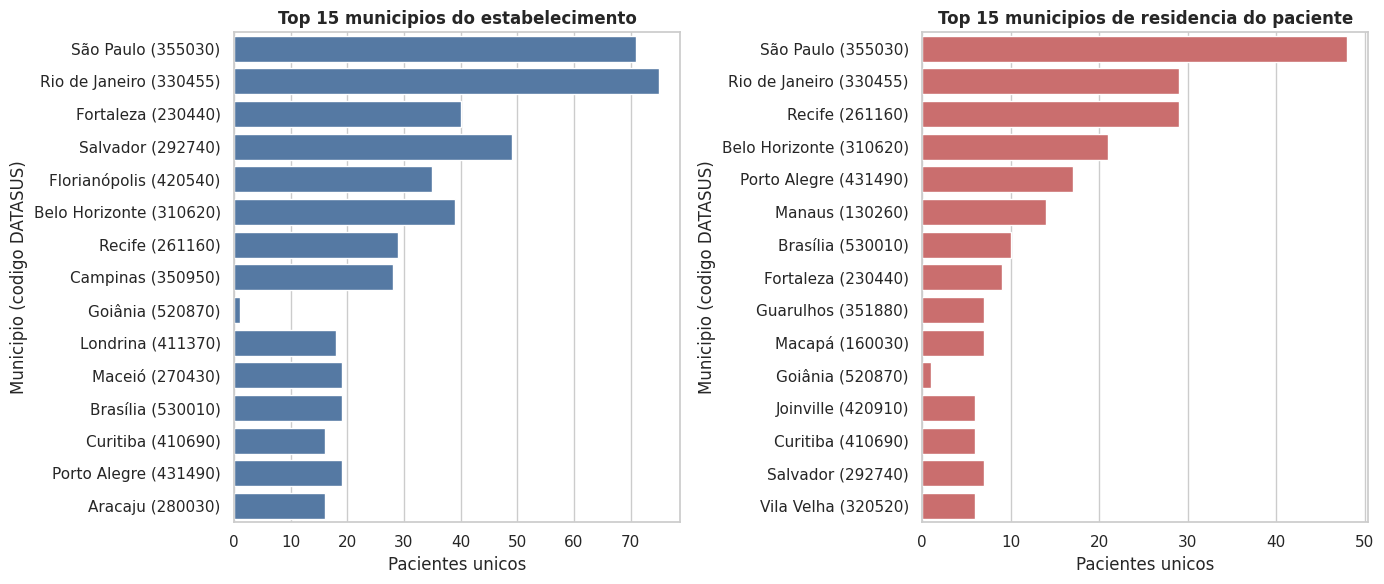

In [19]:
ibge_mun_parquet = (
    base_dir / "data" / "reference" / "ibge_dtb_2024" / "municipios_ibge_dtb.parquet"
)
if not ibge_mun_parquet.exists():
    raise FileNotFoundError(
        f"Municipios IBGE nao encontrados em {ibge_mun_parquet}. "
        "Execute notebooks/00_ingestao_sia_am.ipynb para baixar o DTB."
    )
mun_parquet_uri = ibge_mun_parquet.resolve().as_posix().replace("'", "''")
con.execute(
    f"""
    CREATE OR REPLACE VIEW vw_ibge_municipio AS
    SELECT *
    FROM read_parquet('{mun_parquet_uri}')
    """
)

df_top_mun_estab = con.execute(
    """
    SELECT
        t.cd_uf_municipio_estabelecimento AS cd_municipio_datasus,
        m.nm_municipio,
        COUNT(*) AS qt_apacs,
        COUNT(DISTINCT t.cd_cns_paciente) AS qt_pacientes
    FROM tb_apac_medicamento_gaucher t
    LEFT JOIN vw_ibge_municipio m
        ON m.cd_mun_datasus = lpad(cast(t.cd_uf_municipio_estabelecimento AS VARCHAR), 6, '0')
    GROUP BY 1, 2
    ORDER BY qt_apacs DESC
    LIMIT 15;
    """
).df()


def _rotulo_municipio(row):
    nm = row["nm_municipio"]
    cd = str(row["cd_municipio_datasus"])
    if nm is None or (isinstance(nm, float) and pd.isna(nm)):
        return cd
    s = str(nm).strip()
    return f"{s} ({cd})" if s else cd


df_top_mun_estab["rotulo_municipio"] = df_top_mun_estab.apply(_rotulo_municipio, axis=1)

df_top_mun_resid = con.execute(
    """
    SELECT
        t.cd_uf_municipio_residencia AS cd_municipio_datasus,
        m.nm_municipio,
        COUNT(*) AS qt_apacs,
        COUNT(DISTINCT t.cd_cns_paciente) AS qt_pacientes
    FROM tb_apac_medicamento_gaucher t
    LEFT JOIN vw_ibge_municipio m
        ON m.cd_mun_datasus = lpad(cast(t.cd_uf_municipio_residencia AS VARCHAR), 6, '0')
    GROUP BY 1, 2
    ORDER BY qt_apacs DESC
    LIMIT 15;
    """
).df()
df_top_mun_resid["rotulo_municipio"] = df_top_mun_resid.apply(_rotulo_municipio, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(
    data=df_top_mun_estab,
    x="qt_pacientes",
    y="rotulo_municipio",
    color="#4878b0",
    ax=axes[0],
)
axes[0].set_title("Top 15 municipios do estabelecimento")
axes[0].set_ylabel("Municipio (codigo DATASUS)")
axes[0].set_xlabel("Pacientes unicos")

sns.barplot(
    data=df_top_mun_resid,
    x="qt_pacientes",
    y="rotulo_municipio",
    color="#d95f5f",
    ax=axes[1],
)
axes[1].set_title("Top 15 municipios de residencia do paciente")
axes[1].set_ylabel("Municipio (codigo DATASUS)")
axes[1].set_xlabel("Pacientes unicos")

plt.tight_layout()
plt.show()

In [20]:
df_diff = con.execute(
    """
    SELECT
        nm_medicamento,
        SUM(CASE WHEN fl_uf_residencia_diferente IS TRUE THEN 1 ELSE 0 END) AS qt_uf_diff,
        SUM(CASE WHEN fl_municipio_residencia_diferente IS TRUE THEN 1 ELSE 0 END) AS qt_mun_diff,
        COUNT(*) AS qt_total
    FROM tb_apac_medicamento_gaucher
    GROUP BY 1
    ORDER BY 1;
    """
).df()
df_diff["pc_uf_diff"] = (100 * df_diff["qt_uf_diff"] / df_diff["qt_total"]).round(2)
df_diff["pc_mun_diff"] = (100 * df_diff["qt_mun_diff"] / df_diff["qt_total"]).round(2)
df_diff[["nm_medicamento", "pc_uf_diff", "pc_mun_diff", "qt_total"]]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,nm_medicamento,pc_uf_diff,pc_mun_diff,qt_total
0,Alfataliglicerase 200 U,1.74,100.00,2183
1,Alfavelaglicerase 400 U,3.48,100.00,345
2,Imiglucerase 400 U,1.87,100.00,5882
3,Miglustate 100 mg,0.00,100.00,263


## 6. Antropometria e IMC

In [21]:
df_antropo_desc = con.execute(
    """
    SELECT
        'peso_kg (raw)' AS variavel,
        COUNT(nu_peso_kg_num) AS qt,
        AVG(nu_peso_kg_num) AS media,
        MEDIAN(nu_peso_kg_num) AS mediana,
        stddev_pop(nu_peso_kg_num) AS desvio,
        MIN(nu_peso_kg_num) AS minimo,
        MAX(nu_peso_kg_num) AS maximo
    FROM tb_apac_medicamento_gaucher WHERE nu_peso_kg_num > 0
    UNION ALL
    SELECT
        'peso_kg (plausivel)', COUNT(nu_peso_kg_ok),
        AVG(nu_peso_kg_ok), MEDIAN(nu_peso_kg_ok),
        stddev_pop(nu_peso_kg_ok),
        MIN(nu_peso_kg_ok), MAX(nu_peso_kg_ok)
    FROM tb_apac_medicamento_gaucher WHERE nu_peso_kg_ok IS NOT NULL
    UNION ALL
    SELECT
        'altura_cm (plausivel)', COUNT(nu_altura_cm_ok),
        AVG(nu_altura_cm_ok), MEDIAN(nu_altura_cm_ok),
        stddev_pop(nu_altura_cm_ok),
        MIN(nu_altura_cm_ok), MAX(nu_altura_cm_ok)
    FROM tb_apac_medicamento_gaucher WHERE nu_altura_cm_ok IS NOT NULL
    UNION ALL
    SELECT
        'imc', COUNT(nu_imc),
        AVG(nu_imc), MEDIAN(nu_imc),
        stddev_pop(nu_imc),
        MIN(nu_imc), MAX(nu_imc)
    FROM tb_apac_medicamento_gaucher WHERE nu_imc IS NOT NULL;
    """
).df()
df_antropo_desc.round(2)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,variavel,qt,media,mediana,desvio,minimo,maximo
0,peso_kg (raw),8663,96.46,63.00,135.91,6.00,919.00
1,peso_kg (plausivel),8089,62.28,62.00,22.34,6.00,235.00
2,altura_cm (plausivel),8469,158.60,160.00,17.04,60.00,195.00
3,imc,7895,24.60,23.44,11.54,12.03,180.82


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

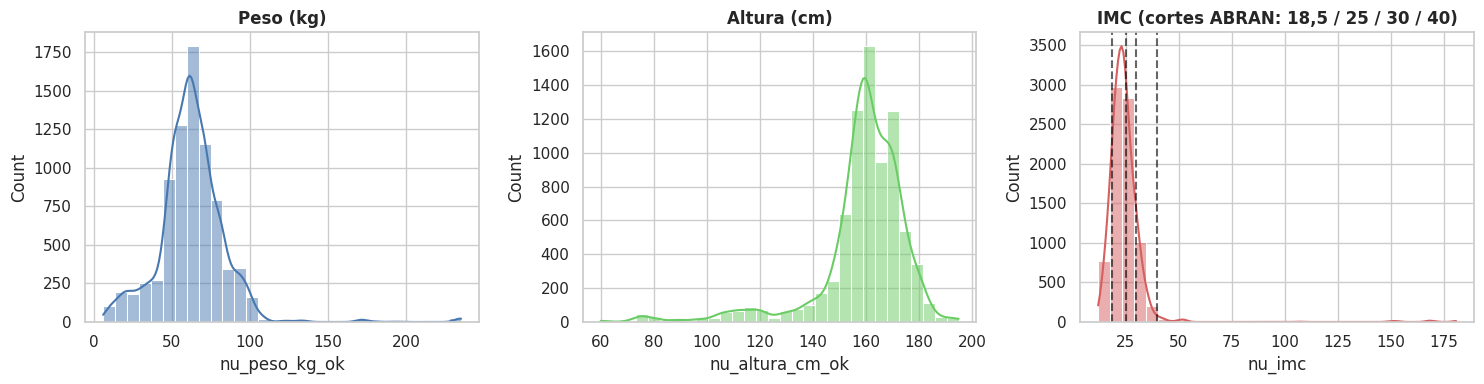

In [22]:
df_antropo = con.execute(
    """
    SELECT nm_medicamento, sg_sexo_paciente, nu_peso_kg_ok, nu_altura_cm_ok, nu_imc, nu_idade_anos
    FROM tb_apac_medicamento_gaucher
    WHERE nu_imc IS NOT NULL;
    """
).df()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(
    df_antropo["nu_peso_kg_ok"], bins=30, kde=True, ax=axes[0], color="#4878b0"
)
axes[0].set_title("Peso (kg)")
sns.histplot(
    df_antropo["nu_altura_cm_ok"], bins=30, kde=True, ax=axes[1], color="#6acc64"
)
axes[1].set_title("Altura (cm)")
sns.histplot(df_antropo["nu_imc"], bins=30, kde=True, ax=axes[2], color="#d65f5f")
axes[2].axvline(18.5, color="black", linestyle="--", alpha=0.6)
axes[2].axvline(25, color="black", linestyle="--", alpha=0.6)
axes[2].axvline(30, color="black", linestyle="--", alpha=0.6)
axes[2].axvline(40, color="black", linestyle="--", alpha=0.6)
axes[2].set_title("IMC (cortes ABRAN: 18,5 / 25 / 30 / 40)")
plt.tight_layout()
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

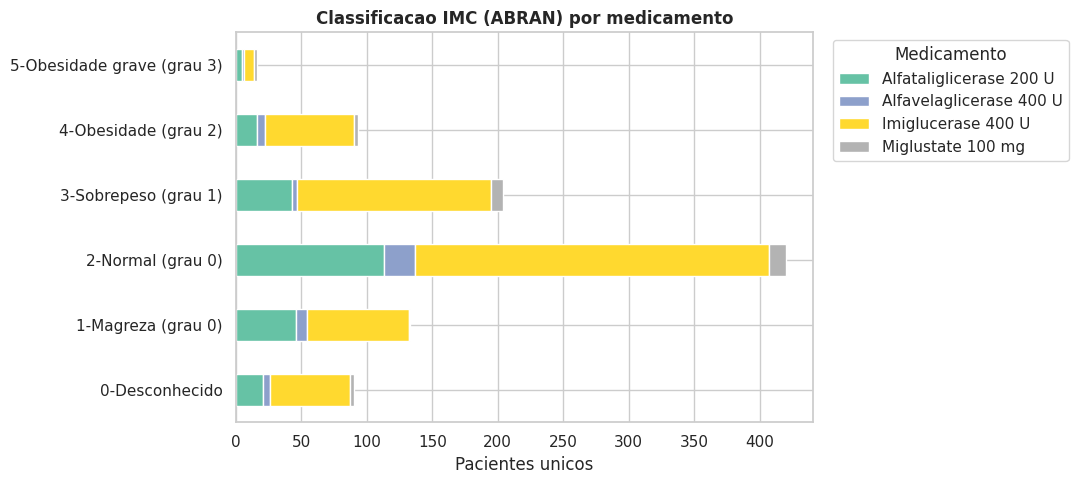

nm_medicamento,Alfataliglicerase 200 U,Alfavelaglicerase 400 U,Imiglucerase 400 U,Miglustate 100 mg
ct_classificacao_imc,,,,
0-Desconhecido,21.00,5.00,61.00,3.00
1-Magreza (grau 0),46.00,8.00,78.00,1.00
2-Normal (grau 0),113.00,24.00,270.00,13.00
3-Sobrepeso (grau 1),43.00,4.00,148.00,9.00
4-Obesidade (grau 2),16.00,6.00,68.00,3.00
5-Obesidade grave (grau 3),5.00,1.00,8.00,2.00


In [23]:
df_imc_abran = con.execute(
    """
    SELECT
        nm_medicamento,
        CASE
            WHEN nu_imc IS NULL THEN '0-Desconhecido'
            WHEN nu_imc < 18.5 THEN '1-Magreza (grau 0)'
            WHEN nu_imc < 25 THEN '2-Normal (grau 0)'
            WHEN nu_imc < 30 THEN '3-Sobrepeso (grau 1)'
            WHEN nu_imc < 40 THEN '4-Obesidade (grau 2)'
            ELSE '5-Obesidade grave (grau 3)'
        END AS ct_classificacao_imc,
        COUNT(DISTINCT cd_cns_paciente) AS qt_pacientes
    FROM tb_apac_medicamento_gaucher
    GROUP BY 1, 2
    ORDER BY 1, 2;
    """
).df()

pivot_imc = df_imc_abran.pivot_table(
    index="ct_classificacao_imc",
    columns="nm_medicamento",
    values="qt_pacientes",
    fill_value=0,
)
_ordem_abran = [
    "0-Desconhecido",
    "1-Magreza (grau 0)",
    "2-Normal (grau 0)",
    "3-Sobrepeso (grau 1)",
    "4-Obesidade (grau 2)",
    "5-Obesidade grave (grau 3)",
]
pivot_imc = pivot_imc.reindex([r for r in _ordem_abran if r in pivot_imc.index])

fig, ax = plt.subplots(figsize=(11, 5))
pivot_imc.plot(kind="barh", stacked=True, ax=ax, colormap="Set2")
ax.set_title("Classificacao IMC (ABRAN) por medicamento")
ax.set_xlabel("Pacientes unicos")
ax.set_ylabel("")
ax.legend(title="Medicamento", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

pivot_imc

## 7. Limitação de custo + Análise de dispensação por paciente
- Panorama dos valores em `vl_apac_aprovada` (deve ser tudo zero)
- Padrao de dispensacao por paciente (regularidade ao longo de 2025)
- Pacientes que trocaram de medicamento durante o ano (switch terapeutico)

In [24]:
con.execute(
    """
    SELECT
        nm_medicamento,
        COUNT(*) AS qt_apacs,
        SUM(CASE WHEN vl_apac_aprovada = 0 THEN 1 ELSE 0 END) AS qt_zero,
        ROUND(100.0 * SUM(CASE WHEN vl_apac_aprovada = 0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pc_zero,
        SUM(CASE WHEN vl_apac_aprovada > 0 THEN 1 ELSE 0 END) AS qt_positivo,
        MIN(vl_apac_aprovada) AS vl_min,
        MAX(vl_apac_aprovada) AS vl_max
    FROM tb_apac_medicamento_gaucher
    GROUP BY ROLLUP(nm_medicamento)
    ORDER BY qt_apacs DESC NULLS FIRST;
    """
).df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,nm_medicamento,qt_apacs,qt_zero,pc_zero,qt_positivo,vl_min,vl_max
0,None,8673,"8,673.00",100.00,0.00,0.00,0.00
1,Imiglucerase 400 U,5882,"5,882.00",100.00,0.00,0.00,0.00
2,Alfataliglicerase 200 U,2183,"2,183.00",100.00,0.00,0.00,0.00
3,Alfavelaglicerase 400 U,345,345.00,100.00,0.00,0.00,0.00
4,Miglustate 100 mg,263,263.00,100.00,0.00,0.00,0.00


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

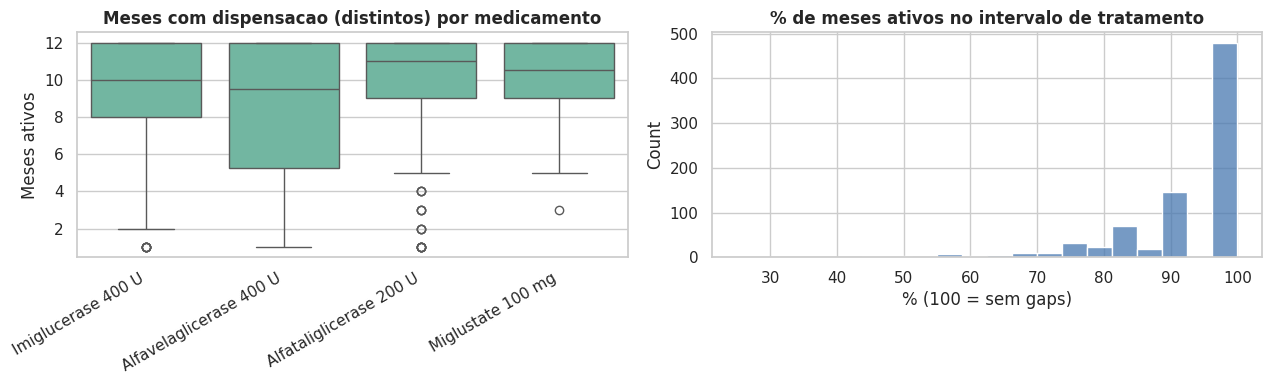

,qt_meses_distintos,qt_meses_cobertos,pc_meses_ativos
count,815.00,815.00,815.00
mean,9.42,10.20,93.20
min,1.00,1.00,25.00
25%,8.00,9.00,89.44
50%,10.00,12.00,100.00
75%,12.00,12.00,100.00
max,12.00,12.00,150.00
std,2.83,2.82,12.21


In [25]:
df_regularidade = con.execute(
    """
    SELECT
        cd_cns_paciente,
        nm_medicamento,
        COUNT(DISTINCT dt_atendimento) AS qt_meses_distintos,
        MIN(dt_competencia_date) AS dt_primeira,
        MAX(dt_competencia_date) AS dt_ultima
    FROM tb_apac_medicamento_gaucher
    WHERE cd_cns_paciente IS NOT NULL
    GROUP BY 1, 2;
    """
).df()
df_regularidade["qt_meses_cobertos"] = (
    df_regularidade["dt_ultima"] - df_regularidade["dt_primeira"]
).dt.days // 30 + 1
df_regularidade["pc_meses_ativos"] = (
    100 * df_regularidade["qt_meses_distintos"] / df_regularidade["qt_meses_cobertos"]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(
    data=df_regularidade, x="nm_medicamento", y="qt_meses_distintos", ax=axes[0]
)
axes[0].set_title("Meses com dispensacao (distintos) por medicamento")
axes[0].set_xlabel("")
axes[0].set_ylabel("Meses ativos")
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")

sns.histplot(
    df_regularidade["pc_meses_ativos"].clip(upper=100),
    bins=20,
    color="#4878b0",
    ax=axes[1],
)
axes[1].set_title("% de meses ativos no intervalo de tratamento")
axes[1].set_xlabel("% (100 = sem gaps)")
plt.tight_layout()
plt.show()

df_regularidade.describe()[
    ["qt_meses_distintos", "qt_meses_cobertos", "pc_meses_ativos"]
].round(2)

In [26]:
df_switch = con.execute(
    """
    SELECT
        cd_cns_paciente,
        COUNT(DISTINCT nm_medicamento) AS qt_medicamentos,
        STRING_AGG(DISTINCT nm_medicamento, ' | ') AS medicamentos,
        COUNT(*) AS qt_apacs
    FROM tb_apac_medicamento_gaucher
    WHERE cd_cns_paciente IS NOT NULL
    GROUP BY 1
    HAVING COUNT(DISTINCT nm_medicamento) > 1
    ORDER BY qt_medicamentos DESC, qt_apacs DESC;
    """
).df()

print(f"Pacientes com >1 medicamento Gaucher em 2025: {len(df_switch)}")
print(f"Sobre {117} pacientes Gaucher unicos = {len(df_switch) / 117 * 100:.1f}%")
df_switch.head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Pacientes com >1 medicamento Gaucher em 2025: 14
Sobre 117 pacientes Gaucher unicos = 12.0%


,cd_cns_paciente,qt_medicamentos,medicamentos,qt_apacs
0,,4,Imiglucerase 400 U | Alfavelaglicerase 400 U |...,1017
1,{}{}|{,3,Alfataliglicerase 200 U | Alfavelaglicerase 40...,12
2,{{|{|{{~,2,Alfavelaglicerase 400 U | Imiglucerase 400 U,14
3,{|~|~~|~,2,Imiglucerase 400 U | Alfavelaglicerase 400 U,14
4,{{|{|{|,2,Imiglucerase 400 U | Alfavelaglicerase 400 U,13
5,{{{{~{{,2,Alfavelaglicerase 400 U | Alfataliglicerase 200 U,12
6,{{{}}}~,2,Alfavelaglicerase 400 U | Imiglucerase 400 U,12
7,{{}}{~}|,2,Imiglucerase 400 U | Alfavelaglicerase 400 U,12
8,{{~{,2,Imiglucerase 400 U | Alfataliglicerase 200 U,11
9,{{{{{{,2,Alfataliglicerase 200 U | Imiglucerase 400 U,9


## 8. Continuidade do tratamento
- Mix de tipos de APAC (inicial vs continuidade)
- Estatisticas de APACs por paciente (tabela abaixo; sem grafico dedicado)
- Quantos pacientes estao com tratamento "ativo" (multiplas APACs em meses distintos)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

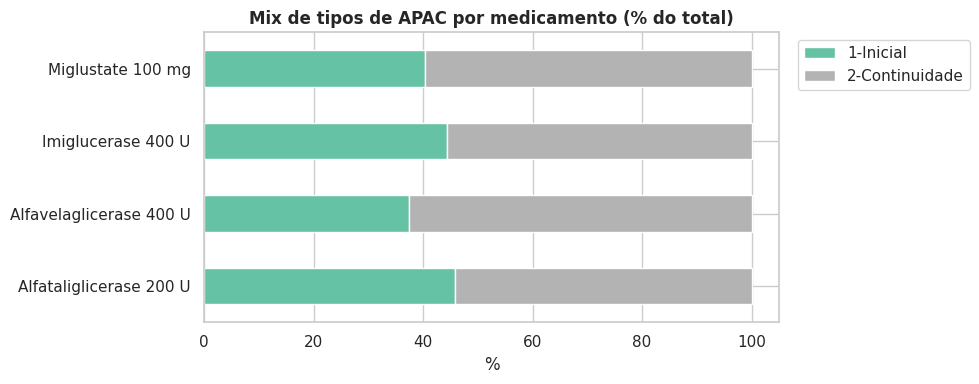

ct_tipo,1-Inicial,2-Continuidade
nm_medicamento,,
Alfataliglicerase 200 U,45.80,54.20
Alfavelaglicerase 400 U,37.40,62.60
Imiglucerase 400 U,44.40,55.60
Miglustate 100 mg,40.30,59.70


In [27]:
df_tipo_apac = con.execute(
    """
    SELECT
        nm_medicamento,
        CASE trim(ct_tipo_apac)
            WHEN '1' THEN '1-Inicial'
            WHEN '2' THEN '2-Continuidade'
            WHEN '3' THEN '3-Unica'
            ELSE '9-Outro/null'
        END AS ct_tipo,
        COUNT(*) AS qt_apacs
    FROM tb_apac_medicamento_gaucher
    GROUP BY 1, 2
    ORDER BY 1, 2;
    """
).df()

pivot_tipo = df_tipo_apac.pivot_table(
    index="nm_medicamento",
    columns="ct_tipo",
    values="qt_apacs",
    fill_value=0,
)
pivot_tipo_pc = pivot_tipo.div(pivot_tipo.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 4))
pivot_tipo_pc.plot(kind="barh", stacked=True, ax=ax, colormap="Set2")
ax.set_title("Mix de tipos de APAC por medicamento (% do total)")
ax.set_xlabel("%")
ax.set_ylabel("")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
pivot_tipo_pc.round(1)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

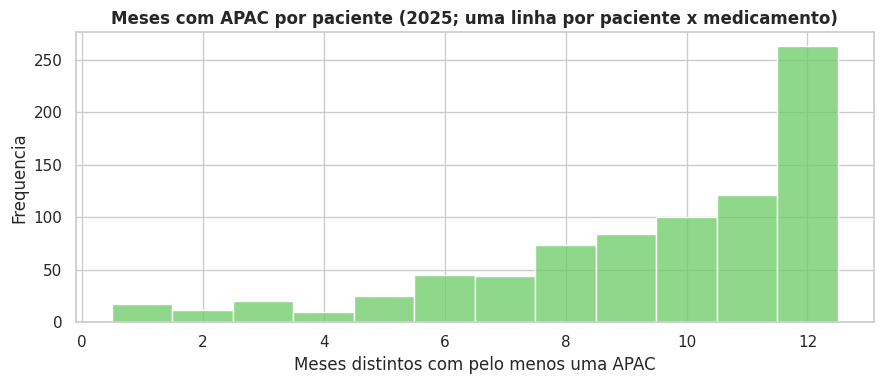

,count,mean,50%,std,min,max
qt_apacs,815.00,10.64,10.00,28.68,1.00,807.00
qt_meses_distintos,815.00,9.42,10.00,2.83,1.00,12.00


In [28]:
df_apacs_por_paciente = con.execute(
    """
    SELECT
        cd_cns_paciente,
        nm_medicamento,
        COUNT(*) AS qt_apacs,
        COUNT(DISTINCT dt_atendimento) AS qt_meses_distintos
    FROM tb_apac_medicamento_gaucher
    WHERE cd_cns_paciente IS NOT NULL
    GROUP BY 1, 2;
    """
).df()

fig, ax = plt.subplots(figsize=(9, 4))
mx_m = int(df_apacs_por_paciente["qt_meses_distintos"].max())
sns.histplot(
    df_apacs_por_paciente["qt_meses_distintos"],
    bins=np.arange(0.5, mx_m + 1.5, 1),
    ax=ax,
    color="#6acc64",
)
ax.set_title("Meses com APAC por paciente (2025; uma linha por paciente x medicamento)")
ax.set_xlabel("Meses distintos com pelo menos uma APAC")
ax.set_ylabel("Frequencia")
plt.tight_layout()
plt.show()

df_apacs_por_paciente.describe().T[["count", "mean", "50%", "std", "min", "max"]].round(
    2
)

## 9. CIDs e comorbidades

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

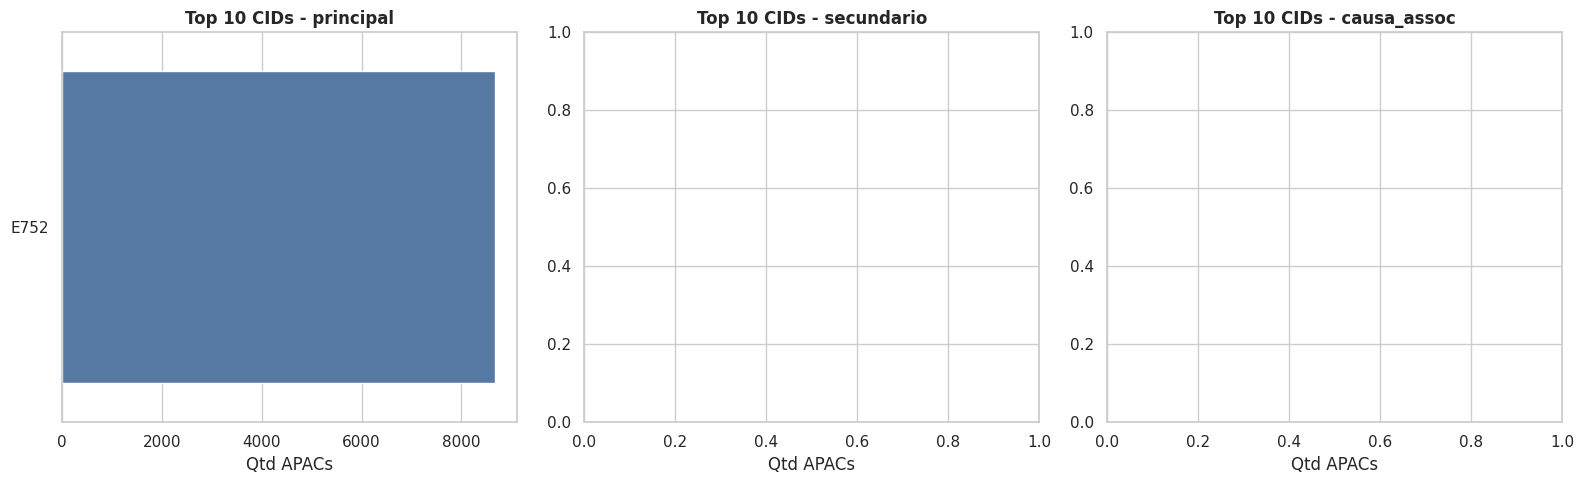

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,qt_gaucher_principal,qt_total,pc
0,"8,673.00",8673,100.00


In [29]:
df_cids = con.execute(
    """
    WITH unpvt AS (
        SELECT 'principal'  AS origem, cd_cid_principal      AS cid FROM tb_apac_medicamento_gaucher
        UNION ALL
        SELECT 'secundario' AS origem, cd_cid_secundario     AS cid FROM tb_apac_medicamento_gaucher
        UNION ALL
        SELECT 'causa_assoc' AS origem, cd_cid_causa_associada AS cid FROM tb_apac_medicamento_gaucher
    )
    SELECT origem, cid, COUNT(*) AS qt
    FROM unpvt
    WHERE cid IS NOT NULL AND trim(cid) <> ''
    GROUP BY 1, 2
    ORDER BY origem, qt DESC;
    """
).df()

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=False)
for ax, origem in zip(axes, ["principal", "secundario", "causa_assoc"]):
    top = df_cids[df_cids["origem"] == origem].head(10)
    sns.barplot(data=top, x="qt", y="cid", ax=ax, color="#4878b0")
    ax.set_title(f"Top 10 CIDs - {origem}")
    ax.set_xlabel("Qtd APACs")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

con.execute(
    """
    SELECT
        SUM(CASE WHEN trim(cd_cid_principal) IN ('E752', 'E75.2', 'E75', 'E750', 'E75 ') THEN 1 ELSE 0 END) AS qt_gaucher_principal,
        COUNT(*) AS qt_total,
        ROUND(100.0 * SUM(CASE WHEN trim(cd_cid_principal) IN ('E752', 'E75.2', 'E75', 'E750', 'E75 ') THEN 1 ELSE 0 END) / COUNT(*), 2) AS pc
    FROM tb_apac_medicamento_gaucher;
    """
).df()

## 10. Relacionamento entre variaveis numericas

Variaveis numericas (apos filtros de plausibilidade): `nu_idade_anos`,
`nu_peso_kg`, `nu_altura_cm`, `nu_imc`, `qt_dias_solic_autoriz` e
`qt_transplantes`. Olhamos a matriz de correlacao **Pearson** (relacao
linear) e **Spearman** (relacao monotonica, robusta a distribuicoes nao
normais - lembrando que Shapiro-Wilk rejeitou normalidade para todas).

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

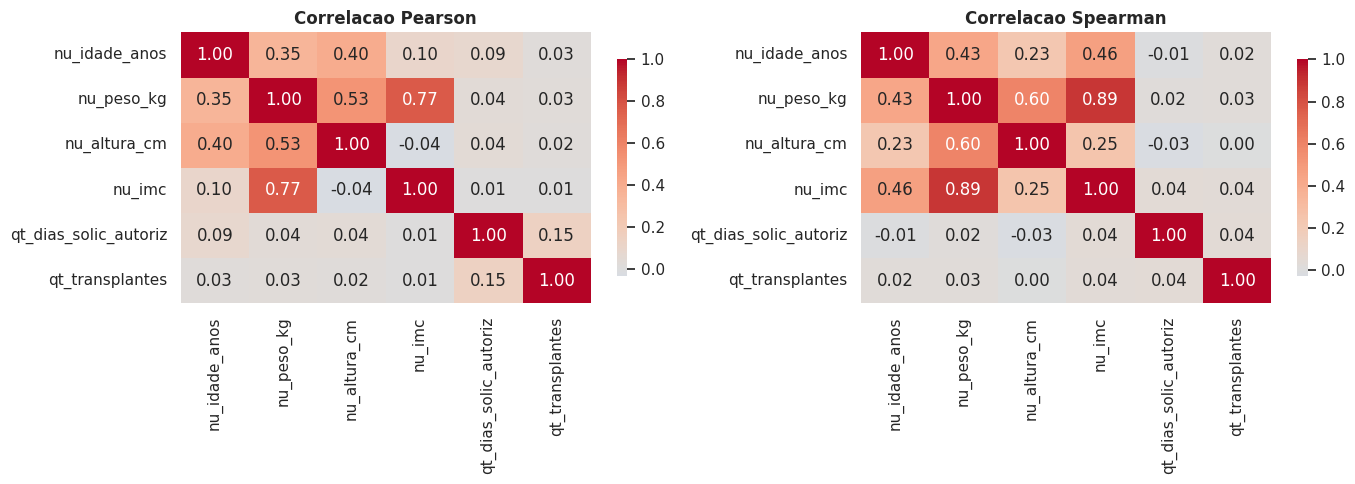

In [30]:
df_num = con.execute(
    """
    SELECT
        nu_idade_anos,
        nu_peso_kg_ok AS nu_peso_kg,
        nu_altura_cm_ok AS nu_altura_cm,
        nu_imc,
        qt_dias_solic_autoriz,
        TRY_CAST(qt_transplantes AS INTEGER) AS qt_transplantes
    FROM tb_apac_medicamento_gaucher
    WHERE nu_idade_anos IS NOT NULL
      AND nu_imc IS NOT NULL;
    """
).df()

corr_pearson = df_num.corr(method="pearson")
corr_spearman = df_num.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(
    corr_pearson,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[0],
    cbar_kws={"shrink": 0.8},
)
axes[0].set_title("Correlacao Pearson")
sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[1],
    cbar_kws={"shrink": 0.8},
)
axes[1].set_title("Correlacao Spearman")
plt.tight_layout()
plt.show()

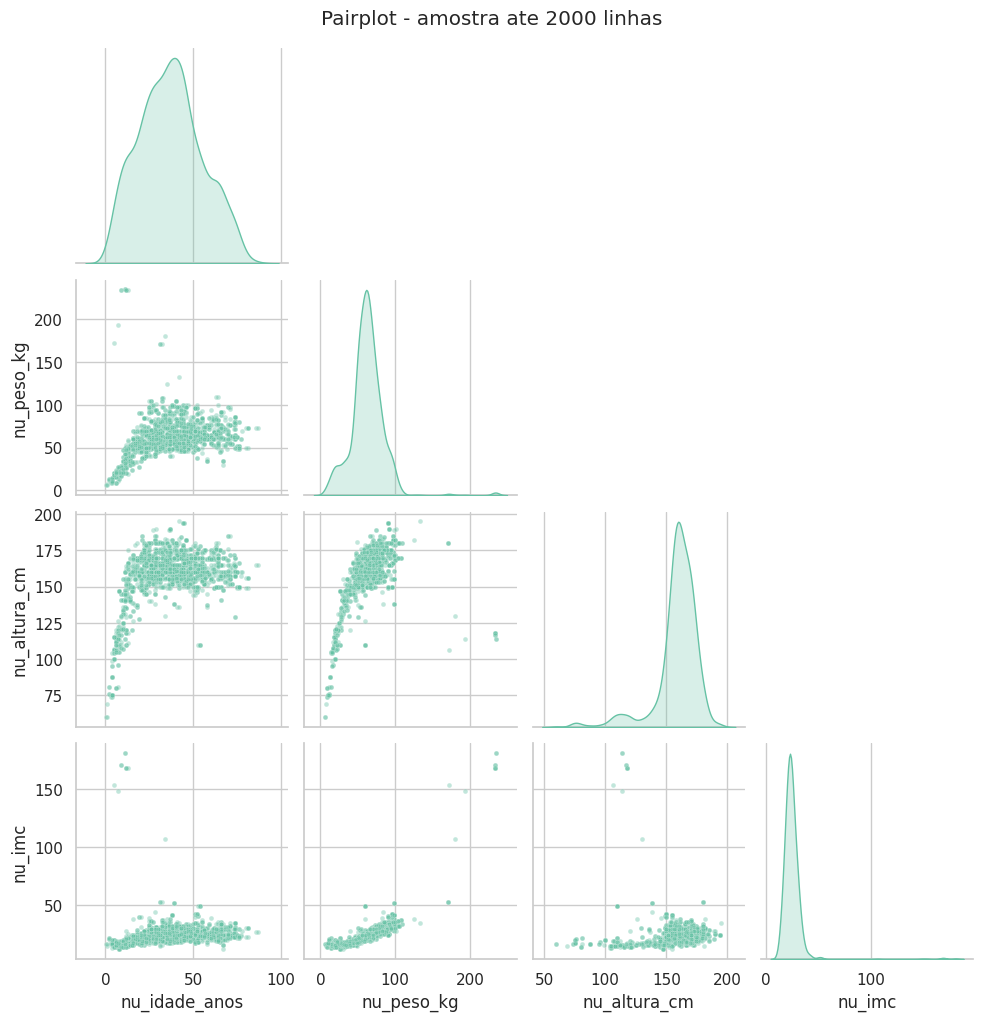

In [31]:
amostra = df_num.sample(n=min(2000, len(df_num)), random_state=42)
sns.pairplot(
    amostra[["nu_idade_anos", "nu_peso_kg", "nu_altura_cm", "nu_imc"]],
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 12},
    corner=True,
)
plt.suptitle("Pairplot - amostra ate 2000 linhas", y=1.02)
plt.show()

## 11. Tempo administrativo: solicitação -> autorização

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Distribuicao do tempo solicitação -> autorização (dias):
                           count  mean  50%   std  min    max
nm_medicamento                                               
Alfataliglicerase 200 U 1,752.00 11.86 0.00 26.16 0.00 190.00
Alfavelaglicerase 400 U   309.00 10.53 0.00 23.68 0.00 154.00
Imiglucerase 400 U      4,498.00 13.64 0.00 25.94 0.00 174.00
Miglustate 100 mg         223.00 10.61 0.00 18.12 0.00 167.00


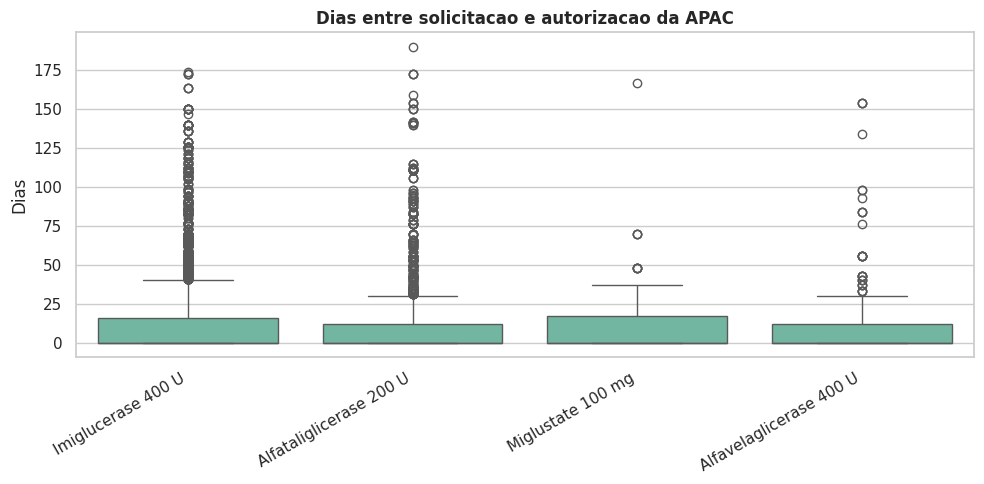

In [32]:
df_proc = con.execute(
    """
    SELECT
        nm_medicamento,
        qt_dias_solic_autoriz
    FROM tb_apac_medicamento_gaucher
    WHERE qt_dias_solic_autoriz IS NOT NULL
      AND qt_dias_solic_autoriz BETWEEN 0 AND 365;
    """
).df()

if df_proc.empty:
    print("Sem datas validas para calcular o tempo solicitacao -> autorizacao.")
else:
    desc = (
        df_proc.groupby("nm_medicamento")["qt_dias_solic_autoriz"]
        .describe()[["count", "mean", "50%", "std", "min", "max"]]
        .round(2)
    )
    print("Distribuicao do tempo solicitação -> autorização (dias):")
    print(desc)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df_proc, x="nm_medicamento", y="qt_dias_solic_autoriz", ax=ax)
    ax.set_title("Dias entre solicitacao e autorizacao da APAC")
    ax.set_xlabel("")
    ax.set_ylabel("Dias")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    plt.tight_layout()
    plt.show()